<a href="https://colab.research.google.com/github/beherapriyanka186-netizen/python_nist/blob/main/play_Tennis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from matplotlib.patches import Rectangle

In [41]:
df=pd.read_csv("/content/drive/MyDrive/ML LAB/play_tennis.csv")
print(df)

     Weather Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


In [42]:
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

def information_gain(df, feature, target):
    total_entropy = entropy(df[target])
    weighted_entropy = 0

    for value in df[feature].unique():
        subset = df[df[feature] == value]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])
    return total_entropy - weighted_entropy

In [43]:
features = ['Weather', 'Temperature', 'Humidity', 'Wind']
print("Entropy =", round(entropy(df['Play']), 4))
gains = {}
for feature in features:
    gains[feature] = information_gain(df, feature, 'Play')
    print("Information Gain of",feature, "=",round(gains[feature], 4))
root_node = max(gains, key=gains.get)
print("\nRoot Node =", root_node)

Entropy = 0.9403
Information Gain of Weather = 0.2467
Information Gain of Temperature = 0.0292
Information Gain of Humidity = 0.1518
Information Gain of Wind = 0.0481

Root Node = Weather


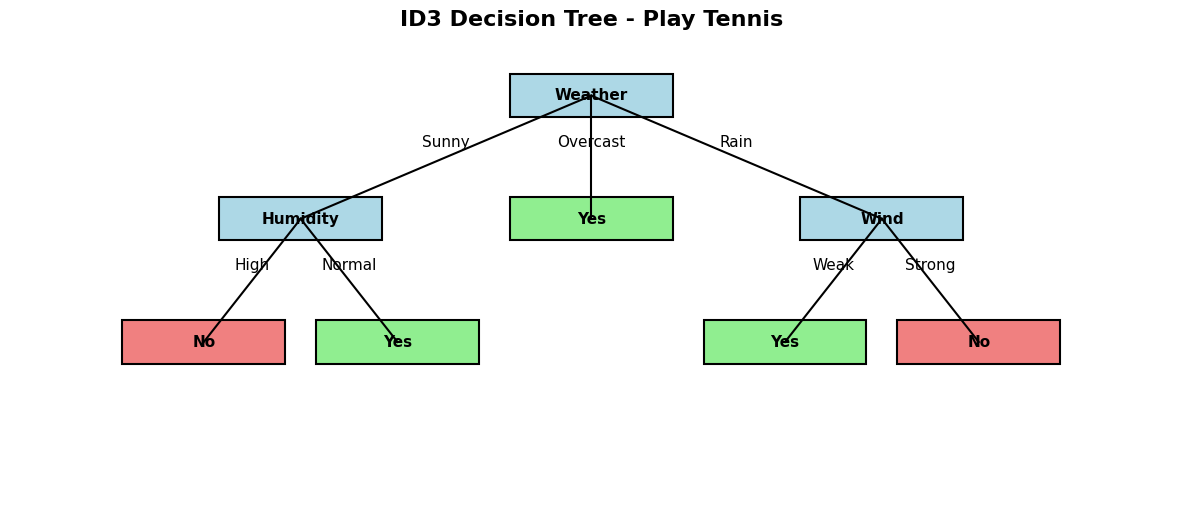

In [37]:
tree = {"Weather": {"Sunny": {"Humidity": {"High": "No","Normal": "Yes"}},"Overcast": "Yes","Rain": {"Wind": {"Weak": "Yes","Strong": "No"}}}}
def get_positions(tree, x=0.5, y=1.0, width=0.5,
                  positions=None, edges=None):
    if positions is None:
        positions = {}
    if edges is None:
        edges = []
    if not isinstance(tree, dict):
        return positions, edges
    feature = list(tree.keys())[0]
    branches = tree[feature]
    positions[id(tree)] = (x, y, feature)
    n = len(branches)
    child_x_positions = np.linspace(x - width / 2,x + width / 2,n)

    for child_x, (value, subtree) in zip(child_x_positions,branches.items()):
        child_y = y - 0.20
        if isinstance(subtree, dict):
            child_feature = list(subtree.keys())[0]
            positions[id(subtree)] = (child_x,child_y,child_feature)
            edges.append((x, y, child_x, child_y, value))
            get_positions(subtree,child_x,child_y,width / max(n, 2),positions,edges)
        else:
            leaf_key = ("leaf",child_x,child_y,value)
            positions[leaf_key] = (child_x,child_y,str(subtree))
            edges.append((x, y, child_x, child_y, value))
    return positions, edges
def plot_id3_tree(tree):
    fig, ax = plt.subplots(figsize=(15, 6))
    positions, edges = get_positions(tree)
    for x1, y1, x2, y2, label in edges:
        ax.plot([x1, x2],[y1, y2],color="black",linewidth=1.5)
        ax.text((x1 + x2) / 2,(y1 + y2) / 2 + 0.025,str(label),ha="center",va="center",fontsize=11)
    for key, (x, y, label) in positions.items():
        if label == "Yes":
            facecolor = "lightgreen"
        elif label == "No":
            facecolor = "lightcoral"
        else:
            facecolor = "lightblue"
        ax.add_patch(Rectangle((x - 0.07, y - 0.035),0.14,0.07,facecolor=facecolor,edgecolor="black",linewidth=1.5))
        ax.text(x,y,label,ha="center",va="center",fontsize=11,fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0.35, 1.1)
    ax.axis("off")
    plt.title("ID3 Decision Tree - Play Tennis",fontsize=16,fontweight="bold")
    plt.show()
plot_id3_tree(tree)